# Лабораторная работа №4

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor, 
                              RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              AdaBoostClassifier, AdaBoostRegressor,
                              StackingClassifier, StackingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, RocCurveDisplay, classification_report)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor

from pycaret.classification import setup as setup_cls, compare_models as compare_cls, pull as pull_cls
from pycaret.regression import setup as setup_reg, compare_models as compare_reg, pull as pull_reg

import optuna

RNG_SEED = 42
np.random.seed(RNG_SEED)

### Загрузка датасетов

In [79]:
df_wine = pd.read_csv('../data/final_data_wine.csv', index_col=0)
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [80]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5974 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5974 non-null   float64
 1   volatile acidity      5974 non-null   float64
 2   citric acid           5974 non-null   float64
 3   residual sugar        5974 non-null   float64
 4   chlorides             5974 non-null   float64
 5   free sulfur dioxide   5974 non-null   float64
 6   total sulfur dioxide  5974 non-null   float64
 7   density               5974 non-null   float64
 8   pH                    5974 non-null   float64
 9   sulphates             5974 non-null   float64
 10  alcohol               5974 non-null   float64
 11  quality               5974 non-null   int64  
 12  type                  5974 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 653.4 KB


In [81]:
df_diamonds = pd.read_csv("../data/final_data_diamonds.csv", index_col=0)
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,326,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,326,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,327,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,334,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,335,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,2757,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,2757,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,2757,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,2757,0.373383,0.346954,0.290021


In [82]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.5 MB


### Выделеение целевого признака и предиктора, разделение на выборки

In [83]:
X_wine = df_wine.drop(columns=['type'])
y_wine = df_wine['type']
print(X_wine.shape, y_wine.shape)
print(y_wine.value_counts())

(5974, 12) (5974,)
type
0    4575
1    1399
Name: count, dtype: int64


In [84]:
X_diamonds = df_diamonds.drop(columns=["price"])
y_diamonds = df_diamonds['price']
print(X_diamonds.shape, y_diamonds.shape)
print(y_diamonds.value_counts())

(53940, 9) (53940,)
price
605      132
802      127
625      126
828      125
776      124
        ... 
8816       1
14704      1
14699      1
14698      1
9793       1
Name: count, Length: 11602, dtype: int64


### Разделение данных

In [85]:
X_temp_wine, X_test_wine, y_temp_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=RNG_SEED)
X_train_wine, X_val_wine, y_train_wine, y_val_wine = train_test_split(X_temp_wine, y_temp_wine, test_size=0.25, stratify=y_temp_wine, random_state=RNG_SEED)

print(X_train_wine.shape, X_val_wine.shape, X_test_wine.shape)
print(y_train_wine.shape, X_val_wine.shape, y_test_wine.shape)


(3584, 12) (1195, 12) (1195, 12)
(3584,) (1195, 12) (1195,)


In [86]:
X_temp_diamonds, X_test_diamonds, y_temp_diamonds, y_test_diamonds = train_test_split(X_diamonds, y_diamonds, test_size=0.2, random_state=RNG_SEED)
X_train_diamonds, X_val_diamonds, y_train_diamonds, y_val_diamonds = train_test_split(X_temp_diamonds, y_temp_diamonds, test_size=0.25, random_state=RNG_SEED)

print(X_train_diamonds.shape, X_val_diamonds.shape, X_test_diamonds.shape)
print(y_train_diamonds.shape, X_val_diamonds.shape, y_test_diamonds.shape)

(32364, 9) (10788, 9) (10788, 9)
(32364,) (10788, 9) (10788,)


### Балансировка

In [87]:
y_train_wine.value_counts()

type
0    2745
1     839
Name: count, dtype: int64

In [88]:
oversample = SMOTE()

X_train_bal_wine, y_train_bal_wine = oversample.fit_resample(X_train_wine, y_train_wine)
y_train_bal_wine.value_counts()

type
0    2745
1    2745
Name: count, dtype: int64

### Вспомогательные функции

In [89]:
def calculate_metrics_cls(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1': f1_score(y_true, y_pred, average='weighted')
    }

def calculate_metrics_reg(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


def print_cv_results_table(cv_scores, model_name="Model"):
    metric_mapping = {
        'F1': 'test_f1_weighted',
        'Accuracy': 'test_accuracy',
        'Precision': 'test_precision_weighted',
        'Recall': 'test_recall_weighted'
    }
    
    data = {'Fold': list(range(len(cv_scores['test_accuracy'])))}
    for col_name, key in metric_mapping.items():
        data[col_name] = cv_scores[key]
        
    df = pd.DataFrame(data).set_index('Fold')
    
    df.loc['Mean'] = df.mean()
    df.loc['Std'] = df.std()
    
    print(f"\nРезультаты 10-Fold CV для {model_name}")
    display(df.style.format('{:.4f}').apply(
        lambda row: ['background-color: #FFFF00' if row.name == 'Mean' else '' for _ in row], 
        axis=1
    ))

def fmt(val, metric_name):
    prec = 2 if metric_name == 'F1' or metric_name == 'R2' else 4
    return f"{val:.{prec}f}"


def plot_and_extract_rules(model, X_train, feature_names, max_depth=3):
    plt.figure(figsize=(30, 6))
    plot_tree(model, feature_names=feature_names, class_names=['White', 'Red'], 
              filled=True, max_depth=max_depth, fontsize=10)
    plt.title("Decision Tree Visualization")
    plt.show()
    
    from sklearn.tree import _tree
    def tree_to_rules(tree, feature_names):
        tree_ = tree.tree_
        feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature]
        paths = []
        def recurse(node, path):
            if tree_.feature[node] != _tree.TREE_UNDEFINED:
                name = feature_name[node]
                threshold = tree_.threshold[node]
                recurse(tree_.children_left[node], path + [f"{name} <= {threshold:.2f}"])
                recurse(tree_.children_right[node], path + [f"{name} > {threshold:.2f}"])
            else:
                paths.append(" AND ".join(path))
        recurse(0, [])
        return paths
    
    print("Decision Rules:")
    for rule in tree_to_rules(model, feature_names)[:5]:
        print(f" {rule}")

In [90]:
cls_models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RNG_SEED),
    'Bagging': BaggingClassifier(random_state=RNG_SEED),
    'RandomForest': RandomForestClassifier(random_state=RNG_SEED),
    'GradientBoosting': GradientBoostingClassifier(random_state=RNG_SEED),
    'AdaBoost': AdaBoostClassifier(random_state=RNG_SEED),
    'XGBoost': xgb.XGBClassifier(random_state=RNG_SEED, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=RNG_SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=RNG_SEED, verbose=0),
}

reg_models = {
    'DecisionTree': DecisionTreeRegressor(random_state=RNG_SEED),
    'Bagging': BaggingRegressor(random_state=RNG_SEED),
    'RandomForest': RandomForestRegressor(random_state=RNG_SEED),
    'GradientBoosting': GradientBoostingRegressor(random_state=RNG_SEED),
    'AdaBoost': AdaBoostRegressor(random_state=RNG_SEED),
    'XGBoost': xgb.XGBRegressor(random_state=RNG_SEED),
    'LightGBM': lgb.LGBMRegressor(random_state=RNG_SEED, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RNG_SEED, verbose=0),
}

cv_wine = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
cv_diamonds = KFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

cls_results_wine = []
reg_results_diamonds = []

In [91]:
def train_evaluate_loop(models_dict, X_train, y_train, X_val, y_val, X_test, y_test, cv, task_type, metrics_func, res_list):
    if task_type == 'Classification':
        scorers = {
            'Accuracy': 'accuracy',
            'Precision': 'precision_weighted',
            'Recall': 'recall_weighted',
            'F1': 'f1_weighted'
        }
    else:
        scorers = {
            'R2': 'r2',
            'RMSE': 'neg_root_mean_squared_error',
            'MAE': 'neg_mean_absolute_error',
            'MSE': 'neg_mean_squared_error'
        }

    for name, model in models_dict.items():
        print(f"\n{task_type}: {name}")

        cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scorers, n_jobs=-1)
        
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        metrics_train = metrics_func(y_train, y_pred_train)
        metrics_test = metrics_func(y_test, y_pred_test)
        
        row = {'Algorithm': name}
        for k in metrics_train.keys():
            row[('Train Data', k)] = fmt(metrics_train[k], k)
            row[('Test Data', k)] = fmt(metrics_test[k], k)
            
        for metric_name, scorer_name in scorers.items():
            scores = cv_res[f'test_{metric_name}']
            mean_v, std_v = np.mean(scores), np.std(scores)
            
            if task_type == 'Regression' and metric_name in ['RMSE', 'MAE', 'MSE']:
                mean_v = abs(mean_v)
                
            row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.4f} ± {std_v:.4f}"
            
        res_list.append(row)

        if task_type == 'Classification':
            print("    Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
            RocCurveDisplay.from_estimator(model, X_test, y_test)
            plt.title(f'ROC Curve - {name}')
            plt.show()
        
        print(f"    Train Metrics: { {k: fmt(metrics_train[k], k) for k in metrics_train} }")
        print(f"    Test Metrics: { {k: fmt(metrics_test[k], k) for k in metrics_test} }")
        
        if name == 'DecisionTree' and task_type == 'Classification':
            plot_and_extract_rules(model, X_train, X_train.columns)


Classification: DecisionTree
    Confusion Matrix:
 [[906   9]
 [  6 274]]


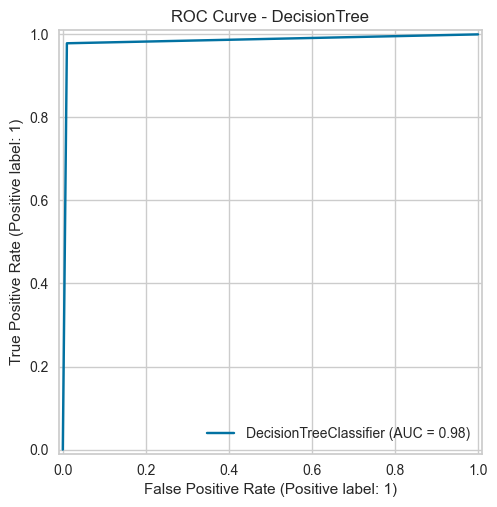

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9874', 'Precision': '0.9875', 'Recall': '0.9874', 'F1': '0.99'}


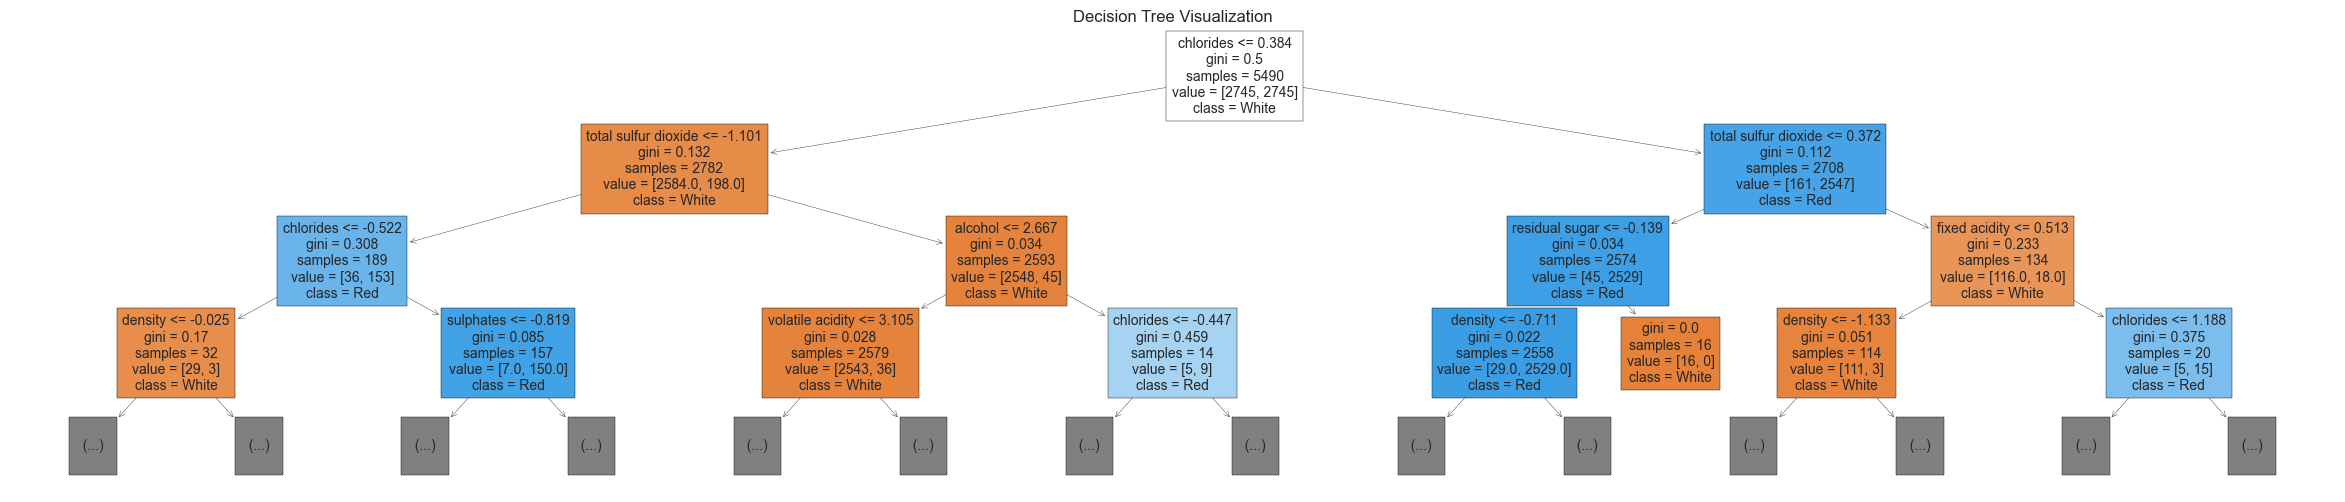

Decision Rules:
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density <= -0.03
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density > -0.03
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides <= 0.06
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides > 0.06
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates > -0.82

Classification: Bagging
    Confusion Matrix:
 [[913   2]
 [  6 274]]


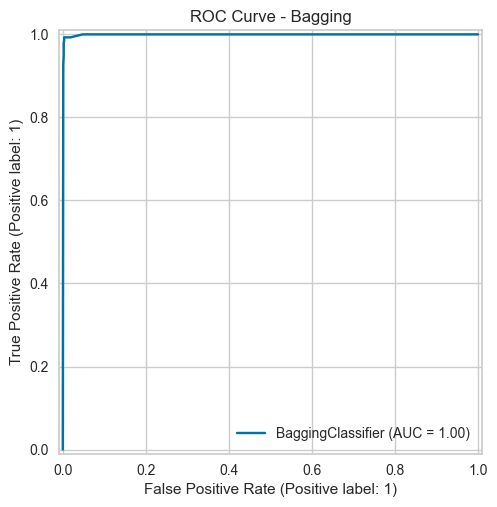

    Train Metrics: {'Accuracy': '0.9989', 'Precision': '0.9989', 'Recall': '0.9989', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9933', 'Precision': '0.9933', 'Recall': '0.9933', 'F1': '0.99'}

Classification: RandomForest
    Confusion Matrix:
 [[914   1]
 [  3 277]]


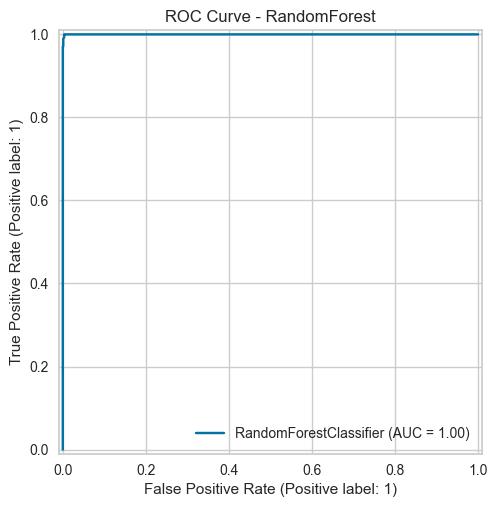

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9967', 'Precision': '0.9967', 'Recall': '0.9967', 'F1': '1.00'}

Classification: GradientBoosting
    Confusion Matrix:
 [[911   4]
 [  4 276]]


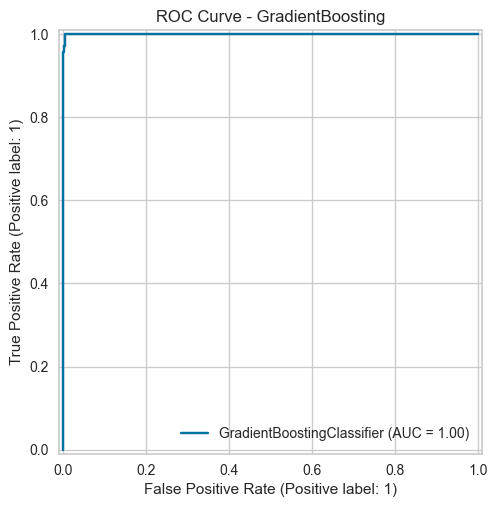

    Train Metrics: {'Accuracy': '0.9995', 'Precision': '0.9995', 'Recall': '0.9995', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9933', 'Precision': '0.9933', 'Recall': '0.9933', 'F1': '0.99'}

Classification: AdaBoost
    Confusion Matrix:
 [[909   6]
 [  2 278]]


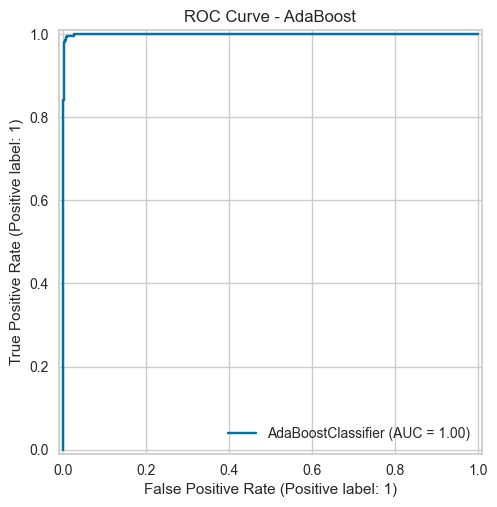

    Train Metrics: {'Accuracy': '0.9973', 'Precision': '0.9973', 'Recall': '0.9973', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9933', 'Precision': '0.9934', 'Recall': '0.9933', 'F1': '0.99'}

Classification: XGBoost
    Confusion Matrix:
 [[912   3]
 [  4 276]]


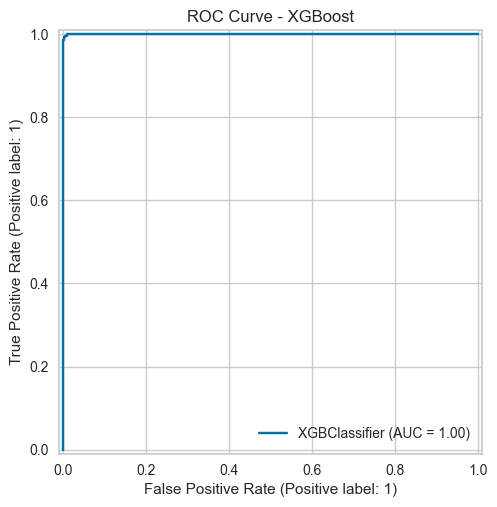

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9941', 'Precision': '0.9941', 'Recall': '0.9941', 'F1': '0.99'}

Classification: LightGBM
    Confusion Matrix:
 [[914   1]
 [  3 277]]


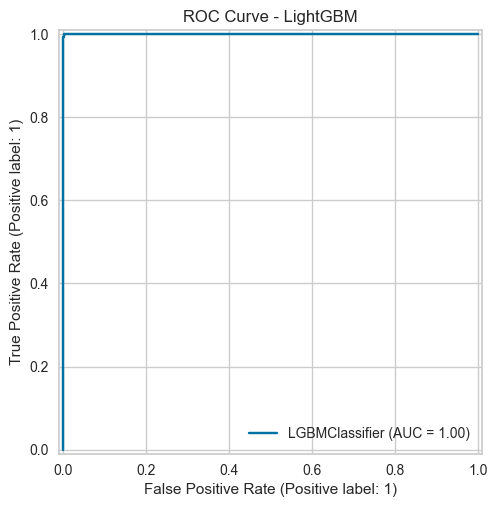

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9967', 'Precision': '0.9967', 'Recall': '0.9967', 'F1': '1.00'}

Classification: CatBoost
    Confusion Matrix:
 [[912   3]
 [  3 277]]


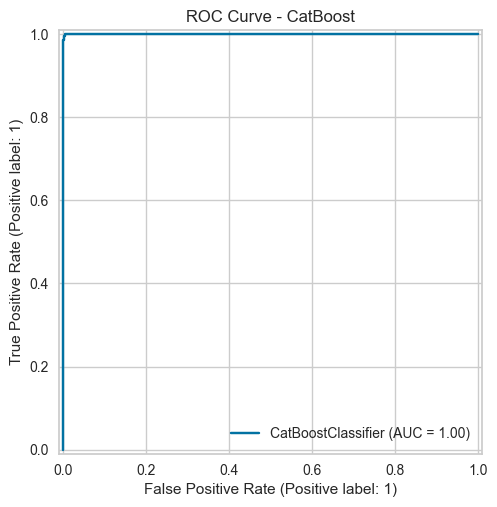

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}


In [92]:
train_evaluate_loop(cls_models, X_train_bal_wine, y_train_bal_wine, X_val_wine, y_val_wine, X_test_wine, y_test_wine, cv_wine, 'Classification', calculate_metrics_cls, cls_results_wine)

In [93]:
train_evaluate_loop(reg_models, X_train_diamonds, y_train_diamonds, X_val_diamonds, y_val_diamonds, X_test_diamonds, y_test_diamonds, cv_diamonds, 'Regression', calculate_metrics_reg, reg_results_diamonds)


Regression: DecisionTree
    Train Metrics: {'MSE': '47.5890', 'RMSE': '6.8985', 'MAE': '0.3618', 'R2': '1.00'}
    Test Metrics: {'MSE': '574116.9167', 'RMSE': '757.7050', 'MAE': '369.5366', 'R2': '0.96'}

Regression: Bagging
    Train Metrics: {'MSE': '57897.3175', 'RMSE': '240.6186', 'MAE': '113.8833', 'R2': '1.00'}
    Test Metrics: {'MSE': '330476.1430', 'RMSE': '574.8705', 'MAE': '287.7034', 'R2': '0.98'}

Regression: RandomForest
    Train Metrics: {'MSE': '41688.3727', 'RMSE': '204.1773', 'MAE': '101.4165', 'R2': '1.00'}
    Test Metrics: {'MSE': '303800.0374', 'RMSE': '551.1806', 'MAE': '273.1247', 'R2': '0.98'}

Regression: GradientBoosting
    Train Metrics: {'MSE': '352712.8376', 'RMSE': '593.8963', 'MAE': '335.2126', 'R2': '0.98'}
    Test Metrics: {'MSE': '366731.1416', 'RMSE': '605.5833', 'MAE': '337.9039', 'R2': '0.98'}

Regression: AdaBoost
    Train Metrics: {'MSE': '1245961.6752', 'RMSE': '1116.2265', 'MAE': '845.5645', 'R2': '0.92'}
    Test Metrics: {'MSE': '12805

In [94]:
reg_results_diamonds

[{'Algorithm': 'DecisionTree',
  ('Train Data', 'MSE'): '47.5890',
  ('Test Data', 'MSE'): '574116.9167',
  ('Train Data', 'RMSE'): '6.8985',
  ('Test Data', 'RMSE'): '757.7050',
  ('Train Data', 'MAE'): '0.3618',
  ('Test Data', 'MAE'): '369.5366',
  ('Train Data', 'R2'): '1.00',
  ('Test Data', 'R2'): '0.96',
  ('K-Fold CV', 'R2 (mean±std)'): '0.9637 ± 0.0027',
  ('K-Fold CV', 'RMSE (mean±std)'): '761.9796 ± 32.2573',
  ('K-Fold CV', 'MAE (mean±std)'): '380.3731 ± 12.1879',
  ('K-Fold CV', 'MSE (mean±std)'): '581653.4721 ± 47960.9530'},
 {'Algorithm': 'Bagging',
  ('Train Data', 'MSE'): '57897.3175',
  ('Test Data', 'MSE'): '330476.1430',
  ('Train Data', 'RMSE'): '240.6186',
  ('Test Data', 'RMSE'): '574.8705',
  ('Train Data', 'MAE'): '113.8833',
  ('Test Data', 'MAE'): '287.7034',
  ('Train Data', 'R2'): '1.00',
  ('Test Data', 'R2'): '0.98',
  ('K-Fold CV', 'R2 (mean±std)'): '0.9785 ± 0.0009',
  ('K-Fold CV', 'RMSE (mean±std)'): '586.7640 ± 15.3069',
  ('K-Fold CV', 'MAE (mean±st

In [95]:
cls_results_wine

[{'Algorithm': 'DecisionTree',
  ('Train Data', 'Accuracy'): '1.0000',
  ('Test Data', 'Accuracy'): '0.9874',
  ('Train Data', 'Precision'): '1.0000',
  ('Test Data', 'Precision'): '0.9875',
  ('Train Data', 'Recall'): '1.0000',
  ('Test Data', 'Recall'): '0.9874',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('K-Fold CV', 'Accuracy (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'Precision (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'Recall (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'F1 (mean±std)'): '0.9893 ± 0.0034'},
 {'Algorithm': 'Bagging',
  ('Train Data', 'Accuracy'): '0.9989',
  ('Test Data', 'Accuracy'): '0.9933',
  ('Train Data', 'Precision'): '0.9989',
  ('Test Data', 'Precision'): '0.9933',
  ('Train Data', 'Recall'): '0.9989',
  ('Test Data', 'Recall'): '0.9933',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('K-Fold CV', 'Accuracy (mean±std)'): '0.9933 ± 0.0015',
  ('K-Fold CV', 'Precision (mean±std)'): '0.9933 ± 0.0015'

In [96]:

print(" Запуск PyCaret для задачи КЛАССИФИКАЦИИ (Wine)...")
setup_cls(data=pd.concat([X_train_bal_wine, y_train_bal_wine], axis=1), 
          target='type', train_size=0.6, fold=5, verbose=False)

best_cls_pycaret = compare_cls(sort='F1', n_select=10)
pycaret_cls_results = pull_cls()

cls_cols = [c for c in ['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'Precision', 'F1', 'F1 Score', 'Kappa'] 
            if c in pycaret_cls_results.columns]
display(pycaret_cls_results[cls_cols])

 Запуск PyCaret для задачи КЛАССИФИКАЦИИ (Wine)...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9951,0.9982,0.9927,0.9976,0.9951,0.9903,0.9903,1.6540
ridge,Ridge Classifier,0.9948,0.9978,0.9927,0.9970,0.9948,0.9897,0.9897,0.1740
lda,Linear Discriminant Analysis,0.9948,0.9978,0.9927,0.9970,0.9948,0.9897,0.9897,0.0380
et,Extra Trees Classifier,0.9948,0.9997,0.9921,0.9976,0.9948,0.9897,0.9897,0.5360
lightgbm,Light Gradient Boosting Machine,0.9945,0.9996,0.9927,0.9964,0.9945,0.9891,0.9891,0.2820
catboost,CatBoost Classifier,0.9942,0.9996,0.9921,0.9964,0.9942,0.9885,0.9885,8.9160
rf,Random Forest Classifier,0.9939,0.9994,0.9897,0.9982,0.9939,0.9879,0.9879,0.9060
svm,SVM - Linear Kernel,0.9933,0.9983,0.9891,0.9976,0.9933,0.9866,0.9867,0.1040
qda,Quadratic Discriminant Analysis,0.9933,0.9983,0.9939,0.9927,0.9933,0.9866,0.9867,0.0440
gbc,Gradient Boosting Classifier,0.9933,0.9988,0.9903,0.9963,0.9933,0.9866,0.9867,1.3120


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa
lr,Logistic Regression,0.9951,0.9982,0.9927,0.9976,0.9951,0.9903
ridge,Ridge Classifier,0.9948,0.9978,0.9927,0.9970,0.9948,0.9897
lda,Linear Discriminant Analysis,0.9948,0.9978,0.9927,0.9970,0.9948,0.9897
et,Extra Trees Classifier,0.9948,0.9997,0.9921,0.9976,0.9948,0.9897
lightgbm,Light Gradient Boosting Machine,0.9945,0.9996,0.9927,0.9964,0.9945,0.9891
catboost,CatBoost Classifier,0.9942,0.9996,0.9921,0.9964,0.9942,0.9885
rf,Random Forest Classifier,0.9939,0.9994,0.9897,0.9982,0.9939,0.9879
svm,SVM - Linear Kernel,0.9933,0.9983,0.9891,0.9976,0.9933,0.9866
qda,Quadratic Discriminant Analysis,0.9933,0.9983,0.9939,0.9927,0.9933,0.9866
gbc,Gradient Boosting Classifier,0.9933,0.9988,0.9903,0.9963,0.9933,0.9866


In [97]:
print("\n\n Запуск PyCaret для задачи РЕГРЕССИИ (Diamonds)...")
setup_reg(data=pd.concat([X_train_diamonds, y_train_diamonds], axis=1), 
          target='price', train_size=0.8, fold=5, verbose=False)

best_reg_pycaret = compare_reg(sort='R2', n_select=10)
pycaret_reg_results = pull_reg()

reg_cols = [c for c in ['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'RMSLE'] 
            if c in pycaret_reg_results.columns]
display(pycaret_reg_results[reg_cols])



 Запуск PyCaret для задачи РЕГРЕССИИ (Diamonds)...


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,276.6719,295610.7673,543.1589,0.9814,0.1040,0.0750,5.6220
lightgbm,Light Gradient Boosting Machine,284.6989,299003.0115,546.3780,0.9812,0.1070,0.0817,0.2900
et,Extra Trees Regressor,281.4366,316370.0771,561.9551,0.9801,0.0950,0.0696,4.0980
xgboost,Extreme Gradient Boosting,286.9750,321017.7075,566.2878,0.9798,0.0978,0.0735,0.2720
rf,Random Forest Regressor,283.5103,323472.1171,568.3165,0.9796,0.0943,0.0690,6.0020
gbr,Gradient Boosting Regressor,345.5478,396152.8130,628.9843,0.9751,0.1539,0.1089,1.7600
knn,K Neighbors Regressor,409.3936,588974.5980,767.2147,0.9630,0.1528,0.1176,0.2520
dt,Decision Tree Regressor,383.1024,594364.6663,770.7061,0.9626,0.1284,0.0913,0.1980
ada,AdaBoost Regressor,877.6472,1286794.9293,1133.5115,0.9189,0.4230,0.4486,0.9560
ridge,Ridge Regression,806.3307,1462491.6775,1209.1983,0.9079,0.6561,0.4428,0.0360


,Model,MAE,MSE,RMSE,R2,RMSLE
catboost,CatBoost Regressor,276.6719,2.956108e+05,543.1589,0.9814,0.1040
lightgbm,Light Gradient Boosting Machine,284.6989,2.990030e+05,546.3780,0.9812,0.1070
et,Extra Trees Regressor,281.4366,3.163701e+05,561.9551,0.9801,0.0950
xgboost,Extreme Gradient Boosting,286.9750,3.210177e+05,566.2878,0.9798,0.0978
rf,Random Forest Regressor,283.5103,3.234721e+05,568.3165,0.9796,0.0943
gbr,Gradient Boosting Regressor,345.5478,3.961528e+05,628.9843,0.9751,0.1539
knn,K Neighbors Regressor,409.3936,5.889746e+05,767.2147,0.9630,0.1528
dt,Decision Tree Regressor,383.1024,5.943647e+05,770.7061,0.9626,0.1284
ada,AdaBoost Regressor,877.6472,1.286795e+06,1133.5115,0.9189,0.4230
ridge,Ridge Regression,806.3307,1.462492e+06,1209.1983,0.9079,0.6561


In [ ]:
cls_results_wine

[{'Algorithm': 'DecisionTree',
  ('Train Data', 'Accuracy'): '1.0000',
  ('Test Data', 'Accuracy'): '0.9874',
  ('Train Data', 'Precision'): '1.0000',
  ('Test Data', 'Precision'): '0.9875',
  ('Train Data', 'Recall'): '1.0000',
  ('Test Data', 'Recall'): '0.9874',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('K-Fold CV', 'Accuracy (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'Precision (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'Recall (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'F1 (mean±std)'): '0.9893 ± 0.0034'},
 {'Algorithm': 'Bagging',
  ('Train Data', 'Accuracy'): '0.9989',
  ('Test Data', 'Accuracy'): '0.9933',
  ('Train Data', 'Precision'): '0.9989',
  ('Test Data', 'Precision'): '0.9933',
  ('Train Data', 'Recall'): '0.9989',
  ('Test Data', 'Recall'): '0.9933',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('K-Fold CV', 'Accuracy (mean±std)'): '0.9933 ± 0.0015',
  ('K-Fold CV', 'Precision (mean±std)'): '0.9933 ± 0.0015'

In [119]:
def build_and_display_tables(results_list, task_name, metrics_order):
    print(f"{task_name}")
    df = pd.DataFrame(results_list).set_index('Algorithm')
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    cols_1 = [c for c in df.columns if c[0] in ['Train Data', 'Test Data']]
    cols_1_sorted = sorted(cols_1, key=lambda c: (0 if c[0]=='Train Data' else 1, metrics_order.index(c[1])))
    table_1 = df[cols_1_sorted]
    display(table_1)
    
    cols_2 = [c for c in df.columns if c[0] in ['Test Data', 'K-Fold CV']]
    cols_2_renamed = [('Метод hold-out', c[1]) if c[0] == 'Test Data' else c for c in cols_2]
    cols_2_sorted = sorted(cols_2_renamed, key=lambda c: (
        0 if c[0]=='Метод hold-out' else 1, 
        metrics_order.index(c[1].split(' (')[0])
    ))
    table_2 = df[[c for c in df.columns if c[0] in ['Test Data', 'K-Fold CV']]].copy()
    table_2.columns = pd.MultiIndex.from_tuples(cols_2_sorted)
    display(table_2)
    
    return table_1, table_2

cls_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
reg_metrics = ['R2', 'RMSE', 'MAE', 'MSE']

tbl1_cls, tbl2_cls = build_and_display_tables(cls_results_wine, "Классификация (Wine)", cls_metrics)
tbl1_reg, tbl2_reg = build_and_display_tables(reg_results_diamonds, "Регрессия (Diamonds)", reg_metrics)

Классификация (Wine)


Train Data                         Test Data            \
                   Accuracy Precision  Recall    F1  Accuracy Precision   
Algorithm                                                                 
DecisionTree         1.0000    1.0000  1.0000  1.00    0.9874    0.9875   
Bagging              0.9989    0.9989  0.9989  1.00    0.9933    0.9933   
RandomForest         1.0000    1.0000  1.0000  1.00    0.9967    0.9967   
GradientBoosting     0.9995    0.9995  0.9995  1.00    0.9933    0.9933   
AdaBoost             0.9973    0.9973  0.9973  1.00    0.9933    0.9934   
XGBoost              1.0000    1.0000  1.0000  1.00    0.9941    0.9941   
LightGBM             1.0000    1.0000  1.0000  1.00    0.9967    0.9967   
CatBoost             1.0000    1.0000  1.0000  1.00    0.9950    0.9950   

                                
                  Recall    F1  
Algorithm                       
DecisionTree      0.9874  0.99  
Bagging           0.9933  0.99  
RandomForest      0.9967  1.00  
GradientBoosting  0.9933  0.99  
AdaBoost          0.9933  0.99  
XGBoost           0.9941  0.99  
LightGBM          0.9967  1.00  
CatBoost          0.9950  0.99

Метод hold-out                                   K-Fold CV  \
                       Accuracy Precision  Recall    F1 Accuracy (mean±std)   
Algorithm                                                                     
DecisionTree             0.9874    0.9875  0.9874  0.99     0.9893 ± 0.0034   
Bagging                  0.9933    0.9933  0.9933  0.99     0.9933 ± 0.0015   
RandomForest             0.9967    0.9967  0.9967  1.00     0.9956 ± 0.0018   
GradientBoosting         0.9933    0.9933  0.9933  0.99     0.9949 ± 0.0027   
AdaBoost                 0.9933    0.9934  0.9933  0.99     0.9936 ± 0.0023   
XGBoost                  0.9941    0.9941  0.9941  0.99     0.9958 ± 0.0017   
LightGBM                 0.9967    0.9967  0.9967  1.00     0.9958 ± 0.0019   
CatBoost                 0.9950    0.9950  0.9950  0.99     0.9964 ± 0.0012   

                                                                          
                 Precision (mean±std) Recall (mean±std)    F1 (mean±std)  
Algorithm                                                                 
DecisionTree          0.9893 ± 0.0034   0.9893 ± 0.0034  0.9893 ± 0.0034  
Bagging               0.9933 ± 0.0015   0.9933 ± 0.0015  0.9933 ± 0.0015  
RandomForest          0.9957 ± 0.0018   0.9956 ± 0.0018  0.9956 ± 0.0018  
GradientBoosting      0.9949 ± 0.0027   0.9949 ± 0.0027  0.9949 ± 0.0027  
AdaBoost              0.9936 ± 0.0023   0.9936 ± 0.0023  0.9936 ± 0.0023  
XGBoost               0.9958 ± 0.0017   0.9958 ± 0.0017  0.9958 ± 0.0017  
LightGBM              0.9958 ± 0.0019   0.9958 ± 0.0019  0.9958 ± 0.0019  
CatBoost              0.9964 ± 0.0011   0.9964 ± 0.0012  0.9964 ± 0.0012

Регрессия (Diamonds)


Train Data                                    Test Data  \
                         R2       RMSE       MAE           MSE        R2   
Algorithm                                                                  
DecisionTree           1.00     6.8985    0.3618       47.5890      0.96   
Bagging                1.00   240.6186  113.8833    57897.3175      0.98   
RandomForest           1.00   204.1773  101.4165    41688.3727      0.98   
GradientBoosting       0.98   593.8963  335.2126   352712.8376      0.98   
AdaBoost               0.92  1116.2265  845.5645  1245961.6752      0.92   
XGBoost                0.99   364.3735  209.5104   132768.0757      0.98   
LightGBM               0.99   459.9733  255.5454   211575.3944      0.98   
CatBoost               0.99   414.1394  233.4237   171511.4598      0.98   

                                                     
                       RMSE       MAE           MSE  
Algorithm                                            
DecisionTree       757.7050  369.5366   574116.9167  
Bagging            574.8705  287.7034   330476.1430  
RandomForest       551.1806  273.1247   303800.0374  
GradientBoosting   605.5833  337.9039   366731.1416  
AdaBoost          1131.6233  855.3261  1280571.2541  
XGBoost            538.4275  274.0915   289904.1666  
LightGBM           540.5021  280.0365   292142.5190  
CatBoost           529.9435  269.6883   280840.0622

Метод hold-out                                   K-Fold CV  \
                             R2       RMSE       MAE   MSE    R2 (mean±std)   
Algorithm                                                                     
DecisionTree        574116.9167   757.7050  369.5366  0.96  0.9637 ± 0.0027   
Bagging             330476.1430   574.8705  287.7034  0.98  0.9785 ± 0.0009   
RandomForest        303800.0374   551.1806  273.1247  0.98  0.9804 ± 0.0006   
GradientBoosting    366731.1416   605.5833  337.9039  0.98  0.9756 ± 0.0005   
AdaBoost           1280571.2541  1131.6233  855.3261  0.92  0.9194 ± 0.0029   
XGBoost             289904.1666   538.4275  274.0915  0.98  0.9805 ± 0.0012   
LightGBM            292142.5190   540.5021  280.0365  0.98  0.9815 ± 0.0008   
CatBoost            280840.0622   529.9435  269.6883  0.98  0.9823 ± 0.0007   

                                                           \
                      RMSE (mean±std)      MAE (mean±std)   
Algorithm                                                   
DecisionTree       761.9796 ± 32.2573  380.3731 ± 12.1879   
Bagging            586.7640 ± 15.3069   295.4318 ± 8.0983   
RandomForest       560.6818 ± 12.9487   280.3374 ± 8.6580   
GradientBoosting   625.9003 ± 12.6214   345.4352 ± 6.6810   
AdaBoost          1136.3287 ± 28.9625  877.6011 ± 22.1348   
XGBoost            558.5615 ± 20.7874   284.0494 ± 8.0942   
LightGBM           543.9835 ± 16.1229   284.2915 ± 7.4546   
CatBoost           532.0124 ± 13.7744   273.8969 ± 5.6708   

                                             
                             MSE (mean±std)  
Algorithm                                    
DecisionTree       581653.4721 ± 47960.9530  
Bagging            344526.2880 ± 17897.9613  
RandomForest       314531.7595 ± 14410.6835  
GradientBoosting   391910.5278 ± 15721.8653  
AdaBoost          1292081.6718 ± 65788.9058  
XGBoost            312423.0351 ± 23192.7865  
LightGBM           296177.9792 ± 17521.9473  
CatBoost           283226.9274 ± 14669.2709